DATASET SHAPE
(9551, 21)

FIRST 5 ROWS
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, 

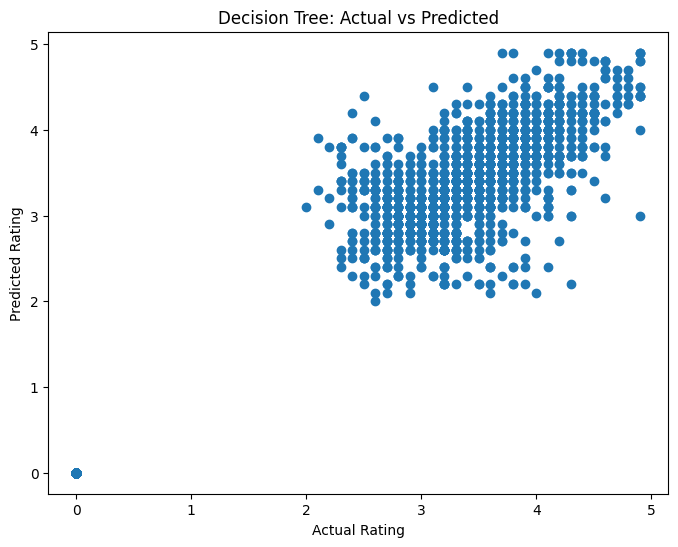


TOP 10 IMPORTANT FEATURES
                 Feature  Importance
12                 Votes    0.947187
2              Longitude    0.016793
3               Latitude    0.011479
4               Cuisines    0.010198
5   Average Cost for two    0.006286
0           Country Code    0.003403
1                   City    0.001340
6               Currency    0.001197
8    Has Online delivery    0.000798
7      Has Table booking    0.000677


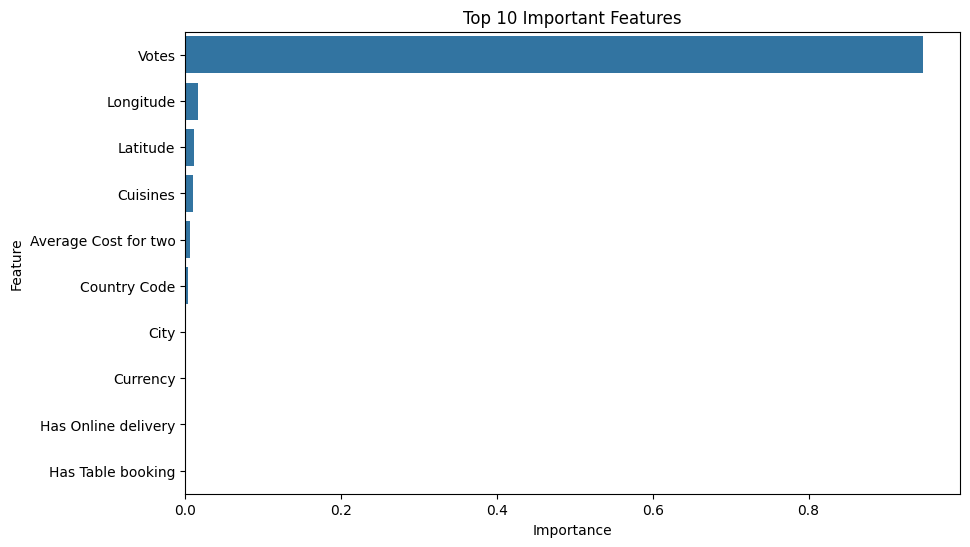


FINAL RESULT
MAE : 0.266
MSE : 0.174
R2 Score : 0.924

Model Successfully Predicted Restaurant Ratings


In [1]:
# ==========================================
# TASK 1 - RESTAURANT RATING PREDICTION
# ==========================================

# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("Dataset.csv")

print("="*50)
print("DATASET SHAPE")
print(df.shape)

print("\n" + "="*50)
print("FIRST 5 ROWS")
print(df.head())

# ==========================================
# DATASET INFORMATION
# ==========================================

print("\n" + "="*50)
print("DATASET INFO")
print(df.info())

print("\n" + "="*50)
print("MISSING VALUES")
print(df.isnull().sum())

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

df.dropna(inplace=True)

print("\n" + "="*50)
print("AFTER REMOVING MISSING VALUES")
print(df.shape)

# ==========================================
# REMOVE UNNECESSARY COLUMNS
# ==========================================

columns_to_drop = [
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Locality',
    'Locality Verbose',
    'Rating color',
    'Rating text'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

# ==========================================
# FEATURES AND TARGET
# ==========================================

y = df['Aggregate rating']
X = df.drop('Aggregate rating', axis=1)

# ==========================================
# ENCODE CATEGORICAL COLUMNS
# ==========================================

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# LINEAR REGRESSION
# ==========================================

print("\n" + "="*50)
print("LINEAR REGRESSION RESULTS")

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("MAE =", mean_absolute_error(y_test, lr_pred))
print("MSE =", mean_squared_error(y_test, lr_pred))
print("R2 Score =", r2_score(y_test, lr_pred))

# ==========================================
# DECISION TREE REGRESSOR
# ==========================================

print("\n" + "="*50)
print("DECISION TREE RESULTS")

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

mae = mean_absolute_error(y_test, dt_pred)
mse = mean_squared_error(y_test, dt_pred)
r2 = r2_score(y_test, dt_pred)

print("MAE =", mae)
print("MSE =", mse)
print("R2 Score =", r2)

# ==========================================
# ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, dt_pred)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n" + "="*50)
print("TOP 10 IMPORTANT FEATURES")
print(importance.head(10))

# ==========================================
# FEATURE IMPORTANCE GRAPH
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

# ==========================================
# FINAL CONCLUSION
# ==========================================

print("\n" + "="*50)
print("FINAL RESULT")

print(f"MAE : {mae:.3f}")
print(f"MSE : {mse:.3f}")
print(f"R2 Score : {r2:.3f}")

print("\nModel Successfully Predicted Restaurant Ratings")